In [163]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [164]:
df = pd.read_excel('tmp.xlsx',sheet_name=
            'each'
        )
df.columns

Index(['Y', '红眼', '橄榄', '冰车', '撑杆', '气球', '矿工', '白眼', '普僵'], dtype='object')

In [165]:
# each 
# 1.313434e+07
# sum 
# 2.0824793e+07
# 


In [166]:
y_df = df['Y']
X_df = df.iloc[:,1:]

X = X_df.to_numpy()
y = y_df.to_numpy()


In [167]:
np.linalg.det(X.T @ X)

18479854762.000027

c:\MyFile\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\MyFile\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


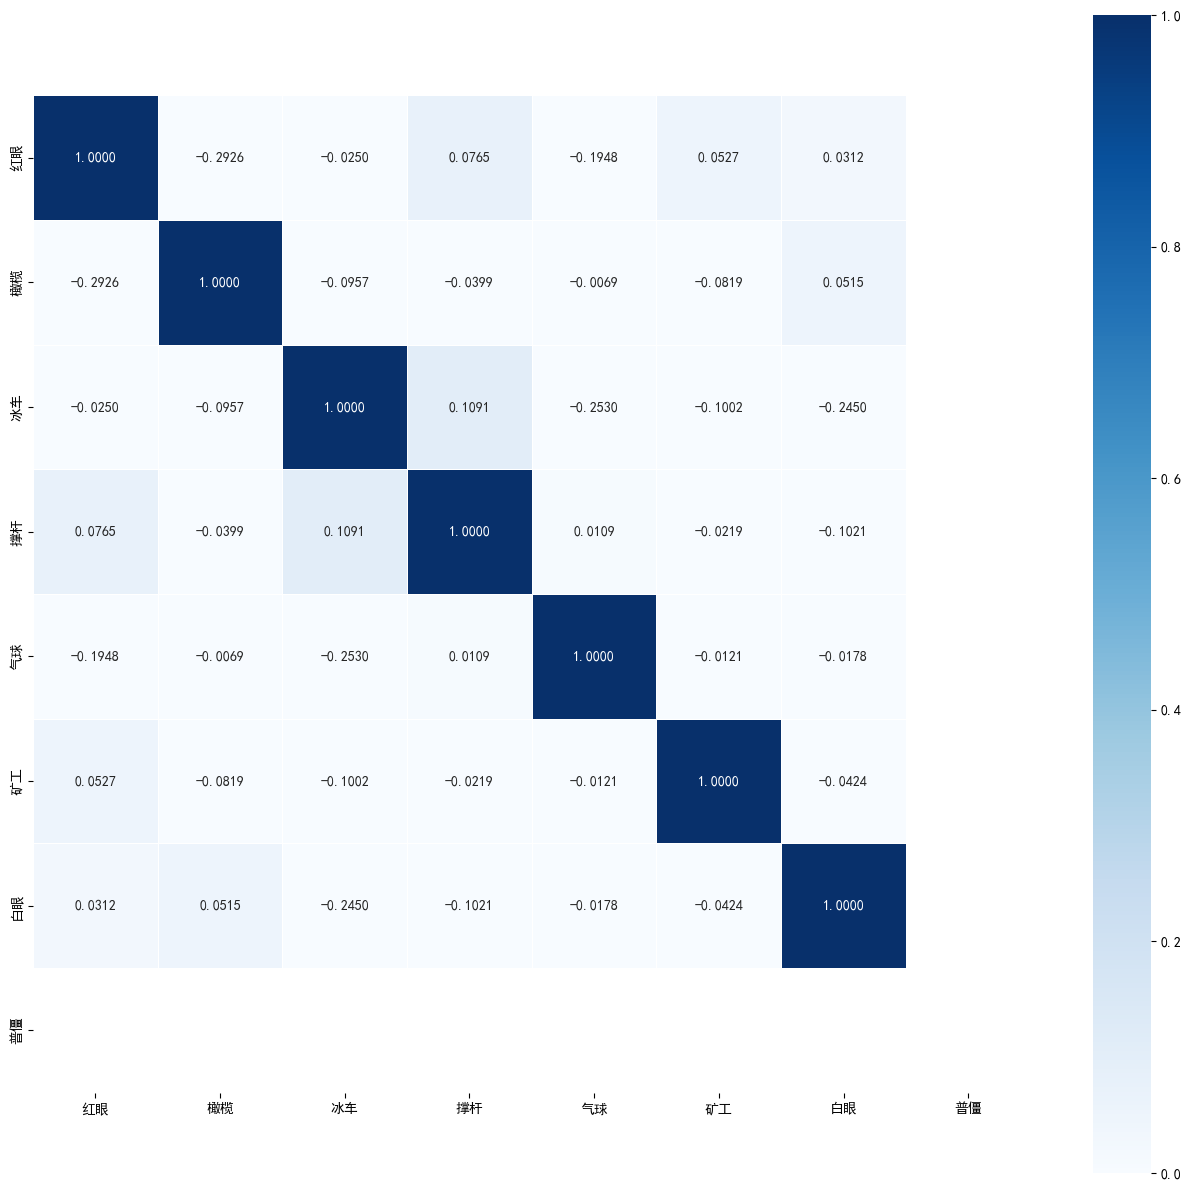

In [168]:
corr_matrix_np = np.corrcoef(X, rowvar=False)  # rowvar=False表示每列是一个变量
# 绘制热力图，使用列名作为坐标轴标签
plt.figure(figsize=(13, 12))
sns.heatmap(
    corr_matrix_np,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    
    square=True,
    linewidths=0.5,
    xticklabels=X_df.columns,  
    yticklabels=X_df.columns   
)

plt.tight_layout()
plt.show()


In [169]:
def OLS_factor_DIY_model(df,main_factors,cross_factors,intercept = True):
    # df['Y'] = -df['Y']
    
    formula = 'Y ~ '
    df_cols = df.columns[~np.isin(df.columns, ['Y'])]

    formula_terms = []
            
    for fact in main_factors:
        formula_terms.append(fact)
    
    for fact in cross_factors:
        formula_terms.append(fact)
            
    formula = formula  + '+'.join(formula_terms)
    if not intercept:
        formula = formula + '+0'
    print(formula)

    model = ols(formula, data=df).fit()

    coefs = model.params
    # 构建带系数的表达式
    coefs = model.params
    formula_parts = []
    if 'Intercept' in coefs:
        formula_parts.append(f"{coefs['Intercept']:.4f}")  # 保留4位小数

    for var, coef in coefs.items():
        if var != 'Intercept':
            formula_parts.append(f"{coef:.4f}*{var}")

    full_expression = "Y = " + " + ".join(formula_parts)
    print("模型表达式:", full_expression)
    
    # 模型摘要
    print(model.summary())
    
    # 方差分析，ANOVA表，显著/不显著效应
    anova_table = sm.stats.anova_lm(model, typ=2,return_type='DataFrame')
    
    SST = model.centered_tss  # 中心化总平方和（即SST）
    SSR = model.mse_model * model.df_model  # 回归平方和
    SSE = model.ssr  # 残差平方和（注意：此处命名可能与数学符号不一致，实际为SSE）

    print("ANOVA 表：")
    print(anova_table)
    print(f"Total     {SST:.6f}")

    significant_effects = anova_table[anova_table['PR(>F)'] < 0.05].index
    print("\n显著效应(p < 0.05):")
    print(significant_effects)
    
    not_significant_effects = anova_table[anova_table['PR(>F)'] > 0.05].index
    print("\n不显著效应(p > 0.05):")
    print(not_significant_effects)
    
    def eta_squared_analysis():
        # 变异性贡献
        contribution = anova_table['sum_sq'] / SST * 100
        plt.figure(figsize=(12, 6))
        contribution.plot(kind='bar')
        plt.title('各因子对总变异的百分比贡献')
        plt.xlabel('因子')
        plt.ylabel('百分比贡献 (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    eta_squared_analysis()

    # 残差分析
    def residuals_analysis():
        df['residuals'] = model.resid
        df['fitted'] = model.fittedvalues

        # 绘制残差分析图
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        stats.probplot((df['residuals']-df['residuals'].mean())/df['residuals'].std(), dist="norm", plot=axes[0])
        axes[0].set_title('残差正态Q-Q图')
        axes[0].set_xlabel('理论分位数')
        axes[0].set_ylabel('样本分位数')

        axes[1].scatter(df['fitted'], df['residuals'])
        axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1].set_title('残差图')
        axes[1].set_xlabel('拟合值')
        axes[1].set_ylabel('残差')

        plt.tight_layout()
        plt.show()
    residuals_analysis()
    
    
    # 临时分析
    residuals = model.resid
    tmp = np.array([residuals.iloc[0]] + [ residuals.iloc[i+1] - residuals.iloc[i] for i in range(len(residuals)-1)])

    
    print((residuals*residuals).sum())
    print((tmp*tmp).sum())
    return model


In [170]:
beta = np.linalg.inv(X.T @ X) @ X.T @ y
beta,3453.64204452/2 + beta.sum()/2

(array([ -617.1211437 , -1274.5805927 ,  -736.08503192,  -181.50365464,
         -571.75439424,  -622.50895805,    69.23324458,  3453.64204452]),
 1486.4817791909545)

Y ~ 红眼+橄榄+冰车+撑杆+气球+矿工+白眼+普僵+0
模型表达式: Y = -617.1211*红眼 + -1274.5806*橄榄 + -736.0850*冰车 + -181.5037*撑杆 + -571.7544*气球 + -622.5090*矿工 + 69.2332*白眼 + 3453.6420*普僵
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     23.28
Date:                Mon, 02 Jun 2025   Prob (F-statistic):           1.10e-15
Time:                        02:58:00   Log-Likelihood:                -559.17
No. Observations:                  75   AIC:                             1134.
Df Residuals:                      67   BIC:                             1153.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|

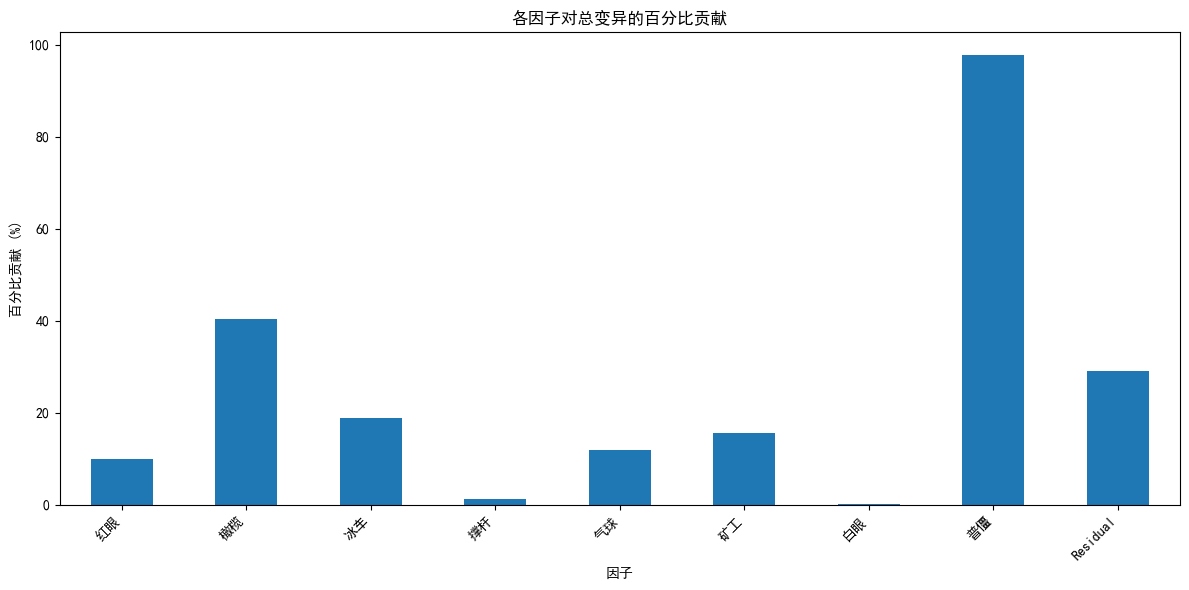

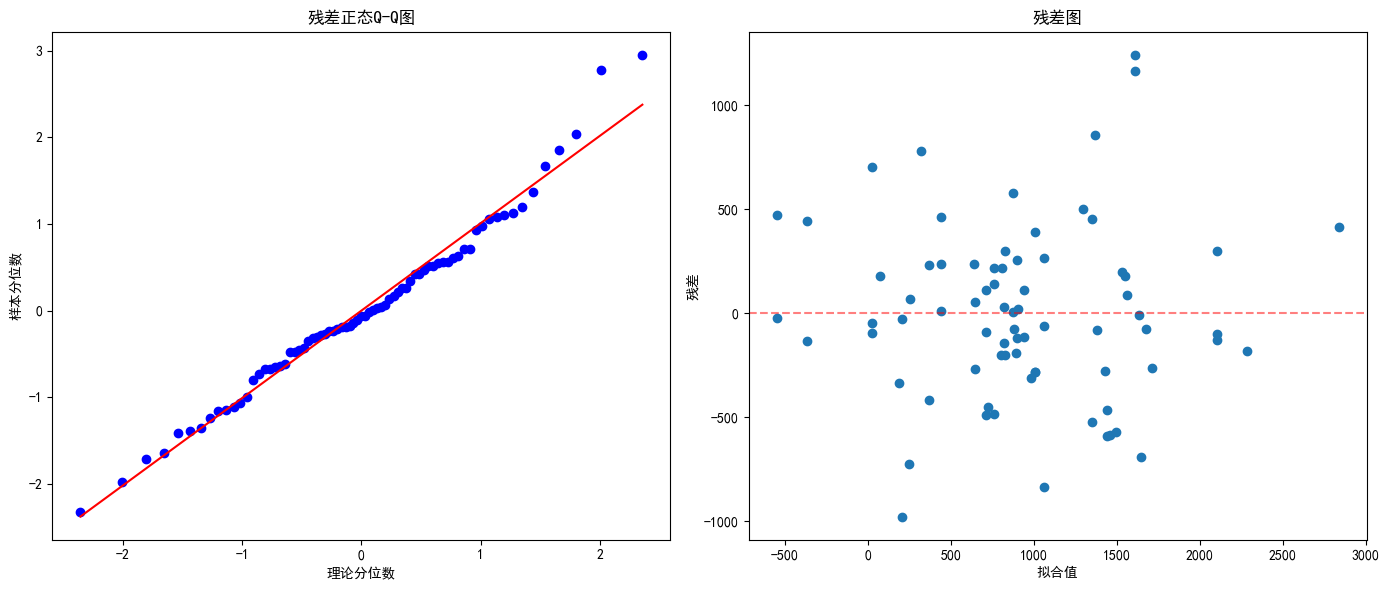

13134341.917443493
23512941.032891117


In [171]:
model = OLS_factor_DIY_model(df,
    [
        '红眼',	'橄榄',	'冰车',	'撑杆',	'气球',	'矿工','白眼',
        '普僵'
    ],[]
    ,False
)

In [172]:
pd.DataFrame(model.params)

,0
红眼,-617.121144
橄榄,-1274.580593
冰车,-736.085032
撑杆,-181.503655
气球,-571.754394
矿工,-622.508958
白眼,69.233245
普僵,3453.642045
